# Why CaSR-Driven Results Has Different Fjord SST

## Weights File Inspection

Weights files were downloaded from https://github.com/SalishSeaCast/grid.

In [1]:
# Paths

import xarray as xr

path_weights_casr='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_weights/weights-CaSR_202108.nc'
path_weights_hrdps='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_weights/weights-continental2.5-hrdps.nc'

ds_weights_casr=xr.open_dataset(path_weights_casr)
ds_weights_hrdps=xr.open_dataset(path_weights_hrdps)

In [2]:
# show variables

print(ds_weights_casr)

<xarray.Dataset> Size: 23MB
Dimensions:  (lat: 105, lon: 70, y: 898, x: 398)
Dimensions without coordinates: lat, lon, y, x
Data variables:
    nav_lat  (lat, lon) float64 59kB ...
    nav_lon  (lat, lon) float64 59kB ...
    src01    (y, x) int64 3MB ...
    wgt01    (y, x) float64 3MB ...
    src02    (y, x) int64 3MB ...
    wgt02    (y, x) float64 3MB ...
    src03    (y, x) int64 3MB ...
    wgt03    (y, x) float64 3MB ...
    src04    (y, x) int64 3MB ...
    wgt04    (y, x) float64 3MB ...
Attributes:
    Conventions:  CF-1.6
    title:        SalishSeaCast NEMO CaSR (Canadian Surface Reanalysis) 10 km...
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    history:      [2026-07-10 16:26:42] Converted to netCDF4 zlib=True datase...
    comment:      For use with forcing files in /ocean/jqiu/CaSR/
    source:       NEMO_EastCoast/NEMO_Preparation/4_weights_ATMOS/get_weight_...
    references:   https://salishsea-meopar-docs.readthedocs.io/en/lates

In [3]:
print(ds_weights_hrdps)

<xarray.Dataset> Size: 24MB
Dimensions:  (lat: 230, lon: 190, y: 898, x: 398)
Dimensions without coordinates: lat, lon, y, x
Data variables:
    nav_lat  (lat, lon) float64 350kB ...
    nav_lon  (lat, lon) float64 350kB ...
    src01    (y, x) int64 3MB ...
    wgt01    (y, x) float64 3MB ...
    src02    (y, x) int64 3MB ...
    wgt02    (y, x) float64 3MB ...
    src03    (y, x) int64 3MB ...
    wgt03    (y, x) float64 3MB ...
    src04    (y, x) int64 3MB ...
    wgt04    (y, x) float64 3MB ...
Attributes:
    Conventions:  CF-1.6
    title:        SalishSeaCast NEMO HRDPS 2.5km Continental Rotated Lat/Lon ...
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    source:       NEMO_EastCoast/NEMO_Preparation/4_weights_ATMOS/get_weight_...
    references:   https://salishsea-meopar-docs.readthedocs.io/en/latest/code...
    history:      [2023-03-14 10:19:39] Converted to netCDF4 zlib=True datase...
    comment:      For use with forcing files in /resu

In [ ]:
# T grid index for Sand Heads and Pam Rock

# ============================================================
# Stations
# ============================================================
stations = {
    'Pam Rocks': {
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },

    'Sand Heads': {
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
}


## Track the grid points

In [4]:
# Track function

import xarray as xr
import numpy as np


# ============================================================
# Weight files
# ============================================================

path_weights_casr = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Data_weights/weights-CaSR_202108.nc'
)

path_weights_hrdps = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Data_weights/weights-continental2.5-hrdps.nc'
)

ds_weights_casr = xr.open_dataset(path_weights_casr)
ds_weights_hrdps = xr.open_dataset(path_weights_hrdps)


# ============================================================
# Stations: NEMO T-grid index
# ============================================================

stations = {
    'Pam Rocks': {
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },

    'Sand Heads': {
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
}


# ============================================================
# Function
# ============================================================

def print_atmos_source_points(weights, y, x, name=None):
    """
    Print the atmospheric grid points used to interpolate
    one NEMO target grid point (y, x).

    Parameters
    ----------
    weights : xr.Dataset
        NEMO atmospheric interpolation weights file.
        Must contain:
            nav_lat(lat, lon)
            nav_lon(lat, lon)
            src01..src04(y, x)
            wgt01..wgt04(y, x)

    y, x : int
        Zero-based Python indices of the NEMO target grid point.

    name : str, optional
        Name of the target point, for display.
    """

    nlat = weights.sizes["lat"]
    nlon = weights.sizes["lon"]

    if name is None:
        name = "NEMO point"

    print("=" * 80)
    print(f"{name}")
    print(f"NEMO target index: y={y}, x={x}")
    print(f"Atmospheric source grid: nlat={nlat}, nlon={nlon}")
    print("=" * 80)

    weight_sum = 0.0

    for k in range(1, 5):

        src_name = f"src0{k}"
        wgt_name = f"wgt0{k}"

        # ----------------------------------------------------
        # src is Fortran 1-based linear index
        # ----------------------------------------------------
        src = int(weights[src_name].isel(y=y, x=x).item())
        wgt = float(weights[wgt_name].isel(y=y, x=x).item())

        # Fortran 1-based -> Python 0-based
        idx = src - 1

        # Reverse:
        #
        # Fortran:
        #     src = i + nlon * (j - 1)
        #
        # Python:
        #     idx = ilat * nlon + ilon
        #
        ilat = idx // nlon
        ilon = idx % nlon

        # source atmospheric coordinates
        atmos_lat = float(
            weights["nav_lat"].isel(lat=ilat, lon=ilon).item()
        )

        atmos_lon = float(
            weights["nav_lon"].isel(lat=ilat, lon=ilon).item()
        )

        weight_sum += wgt

        print(
            f"source {k}: "
            f"src={src:6d}, "
            f"(ilat, ilon)=({ilat:4d}, {ilon:4d}), "
            f"lat={atmos_lat:10.6f}, "
            f"lon={atmos_lon:11.6f}, "
            f"weight={wgt:.10f}"
        )

    print("-" * 80)
    print(f"sum(weights) = {weight_sum:.12f}")
    print()

### Print the grid number/ lat and lon

In [5]:
# ============================================================
# CaSR
# ============================================================

print("\n\n#################### CaSR ####################\n")

for station_name, station in stations.items():

    print(
        f"Station coordinate: "
        f"lat={station['lat']}, lon={station['lon']}"
    )

    print_atmos_source_points(
        ds_weights_casr,
        y=station["y"],
        x=station["x"],
        name=station_name,
    )


# ============================================================
# HRDPS
# ============================================================

print("\n\n#################### HRDPS ####################\n")

for station_name, station in stations.items():

    print(
        f"Station coordinate: "
        f"lat={station['lat']}, lon={station['lon']}"
    )

    print_atmos_source_points(
        ds_weights_hrdps,
        y=station["y"],
        x=station["x"],
        name=station_name,
    )



#################### CaSR ####################

Station coordinate: lat=49.487434, lon=-123.30153
Pam Rocks
NEMO target index: y=502, x=341
Atmospheric source grid: nlat=105, nlon=70
source 1: src=  4097, (ilat, ilon)=(  58,   36), lat= 49.483242, lon= 236.676086, weight=0.8099528243
source 2: src=  4027, (ilat, ilon)=(  57,   36), lat= 49.402325, lon= 236.736679, weight=0.0239716401
source 3: src=  4098, (ilat, ilon)=(  58,   37), lat= 49.522491, lon= 236.800385, weight=0.1613015984
source 4: src=  4028, (ilat, ilon)=(  57,   37), lat= 49.441509, lon= 236.860794, weight=0.0047739371
--------------------------------------------------------------------------------
sum(weights) = 1.000000000000

Station coordinate: lat=49.107586, lon=-123.30203
Sand Heads
NEMO target index: y=428, x=293
Atmospheric source grid: nlat=105, nlon=70
source 1: src=  3815, (ilat, ilon)=(  54,   34), lat= 49.081009, lon= 236.670670, weight=0.5675647174
source 2: src=  3885, (ilat, ilon)=(  55,   34), lat= 49.

### Neighboring Grid Points

In [6]:
import xarray as xr
import numpy as np
import pandas as pd


# ============================================================
# Weight files
# ============================================================

path_weights_casr = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Data_weights/weights-CaSR_202108.nc'
)

path_weights_hrdps = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Data_weights/weights-continental2.5-hrdps.nc'
)

ds_weights_casr = xr.open_dataset(path_weights_casr)
ds_weights_hrdps = xr.open_dataset(path_weights_hrdps)


# ============================================================
# Stations
# ============================================================

stations = {
    'Pam Rocks': {
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },

    'Sand Heads': {
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
}


# ============================================================
# Function
# ============================================================

def get_source_and_neighbors(weights, y, x, station_name=None):
    """
    For one NEMO target grid point:

    1. Find the 4 atmospheric source points actually used
       by src01..src04 / wgt01..wgt04.

    2. For each of those 4 source points, find its 8 neighboring
       atmospheric grid points.

    3. Remove duplicates.

    Returns
    -------
    df : pandas.DataFrame

        Columns include:
            point_type
            source_number
            atmos_ilat
            atmos_ilon
            atmos_lat
            atmos_lon
            src
            weight
    """

    nlat = weights.sizes["lat"]
    nlon = weights.sizes["lon"]

    # --------------------------------------------------------
    # Step 1: get the 4 source points actually used by NEMO
    # --------------------------------------------------------

    used_points = {}

    for k in range(1, 5):

        src = int(
            weights[f"src0{k}"]
            .isel(y=y, x=x)
            .item()
        )

        weight = float(
            weights[f"wgt0{k}"]
            .isel(y=y, x=x)
            .item()
        )

        # Fortran 1-based -> Python 0-based
        idx = src - 1

        ilat = idx // nlon
        ilon = idx % nlon

        lat = float(
            weights["nav_lat"]
            .isel(lat=ilat, lon=ilon)
            .item()
        )

        lon = float(
            weights["nav_lon"]
            .isel(lat=ilat, lon=ilon)
            .item()
        )

        used_points[(ilat, ilon)] = {
            "station": station_name,
            "nemo_y": y,
            "nemo_x": x,

            "point_type": "used",
            "source_number": k,

            "src": src,
            "atmos_ilat": ilat,
            "atmos_ilon": ilon,

            "atmos_lat": lat,
            "atmos_lon": lon,

            "weight": weight,
        }


    # --------------------------------------------------------
    # Step 2: find 8 neighbors around EACH used source point
    # --------------------------------------------------------

    neighbor_points = {}

    # 8-connected neighborhood
    offsets = [
        (-1, -1),
        (-1,  0),
        (-1, +1),

        ( 0, -1),
        ( 0, +1),

        (+1, -1),
        (+1,  0),
        (+1, +1),
    ]

    for (ilat0, ilon0), source_info in used_points.items():

        source_number = source_info["source_number"]

        for dy, dx in offsets:

            ilat = ilat0 + dy
            ilon = ilon0 + dx

            # -----------------------------------------------
            # Skip points outside atmospheric grid
            # -----------------------------------------------

            if not (0 <= ilat < nlat):
                continue

            if not (0 <= ilon < nlon):
                continue


            # -----------------------------------------------
            # If this neighbor itself is one of the 4 used
            # points, don't add it as a neighbor
            # -----------------------------------------------

            if (ilat, ilon) in used_points:
                continue


            # -----------------------------------------------
            # Atmospheric coordinates
            # -----------------------------------------------

            lat = float(
                weights["nav_lat"]
                .isel(lat=ilat, lon=ilon)
                .item()
            )

            lon = float(
                weights["nav_lon"]
                .isel(lat=ilat, lon=ilon)
                .item()
            )


            # Python grid index -> Fortran linear index
            src = ilat * nlon + ilon + 1


            # -----------------------------------------------
            # Avoid duplicates
            #
            # The same neighbor may be adjacent to two or
            # more of the 4 interpolation points.
            # -----------------------------------------------

            key = (ilat, ilon)

            if key not in neighbor_points:

                neighbor_points[key] = {
                    "station": station_name,
                    "nemo_y": y,
                    "nemo_x": x,

                    "point_type": "neighbor",

                    # not one of src01..04
                    "source_number": np.nan,

                    "src": src,

                    "atmos_ilat": ilat,
                    "atmos_ilon": ilon,

                    "atmos_lat": lat,
                    "atmos_lon": lon,

                    # neighbor does NOT participate
                    # in the interpolation
                    "weight": np.nan,

                    # useful to know which used point
                    # introduced this neighbor
                    "neighbor_of": [source_number],
                }

            else:

                # This neighbor touches more than one
                # of the four source points
                neighbor_points[key]["neighbor_of"].append(
                    source_number
                )


    # --------------------------------------------------------
    # Combine
    # --------------------------------------------------------

    records = (
        list(used_points.values())
        + list(neighbor_points.values())
    )

    df = pd.DataFrame(records)

    # Sort: used points first, then atmospheric grid location
    df["_sort_type"] = df["point_type"].map({
        "used": 0,
        "neighbor": 1,
    })

    df = (
        df
        .sort_values(
            ["_sort_type", "atmos_ilat", "atmos_ilon"]
        )
        .drop(columns="_sort_type")
        .reset_index(drop=True)
    )

    return df


# ============================================================
# Pretty print
# ============================================================

def print_source_and_neighbors(weights, y, x, station_name=None):

    df = get_source_and_neighbors(
        weights,
        y=y,
        x=x,
        station_name=station_name,
    )

    used = df[df["point_type"] == "used"]
    neighbors = df[df["point_type"] == "neighbor"]

    print()
    print("=" * 100)
    print(f"{station_name}")
    print(f"NEMO target: y={y}, x={x}")
    print("=" * 100)

    print()
    print("********** 4 atmospheric points actually USED **********")
    print()

    for _, row in used.iterrows():

        print(
            f"source {int(row['source_number'])}: "
            f"(ilat, ilon)=({int(row['atmos_ilat']):4d}, "
            f"{int(row['atmos_ilon']):4d})   "
            f"lat={row['atmos_lat']:10.6f}   "
            f"lon={row['atmos_lon']:11.6f}   "
            f"weight={row['weight']:.10f}"
        )

    print()
    print(
        "********** Neighboring atmospheric grid points "
        "(deduplicated) **********"
    )
    print()

    for _, row in neighbors.iterrows():

        print(
            f"(ilat, ilon)=({int(row['atmos_ilat']):4d}, "
            f"{int(row['atmos_ilon']):4d})   "
            f"lat={row['atmos_lat']:10.6f}   "
            f"lon={row['atmos_lon']:11.6f}   "
            f"neighbor_of={row['neighbor_of']}"
        )

    print()
    print("-" * 100)
    print(f"Number of USED points     = {len(used)}")
    print(f"Number of unique neighbors = {len(neighbors)}")
    print(f"Total plotted points       = {len(df)}")

    print(
        f"Sum of interpolation weights = "
        f"{used['weight'].sum():.12f}"
    )

    print()

    return df

In [7]:
# ============================================================
# CaSR
# ============================================================

print("\n######################## CaSR ########################")

casr_results = {}

for station_name, station in stations.items():

    casr_results[station_name] = print_source_and_neighbors(
        ds_weights_casr,
        y=station["y"],
        x=station["x"],
        station_name=station_name,
    )


# ============================================================
# HRDPS
# ============================================================

print("\n######################## HRDPS ########################")

hrdps_results = {}

for station_name, station in stations.items():

    hrdps_results[station_name] = print_source_and_neighbors(
        ds_weights_hrdps,
        y=station["y"],
        x=station["x"],
        station_name=station_name,
    )


######################## CaSR ########################

Pam Rocks
NEMO target: y=502, x=341

********** 4 atmospheric points actually USED **********

source 2: (ilat, ilon)=(  57,   36)   lat= 49.402325   lon= 236.736679   weight=0.0239716401
source 4: (ilat, ilon)=(  57,   37)   lat= 49.441509   lon= 236.860794   weight=0.0047739371
source 1: (ilat, ilon)=(  58,   36)   lat= 49.483242   lon= 236.676086   weight=0.8099528243
source 3: (ilat, ilon)=(  58,   37)   lat= 49.522491   lon= 236.800385   weight=0.1613015984

********** Neighboring atmospheric grid points (deduplicated) **********

(ilat, ilon)=(  56,   35)   lat= 49.282116   lon= 236.673340   neighbor_of=[2]
(ilat, ilon)=(  56,   36)   lat= 49.321369   lon= 236.797089   neighbor_of=[2, 4]
(ilat, ilon)=(  56,   37)   lat= 49.360485   lon= 236.921021   neighbor_of=[2, 4]
(ilat, ilon)=(  56,   38)   lat= 49.399456   lon= 237.045181   neighbor_of=[4]
(ilat, ilon)=(  57,   35)   lat= 49.363010   lon= 236.612778   neighbor_of=[1, 

### Visualize

Pam Rocks extent:
[np.float64(-123.58894165039062), np.float64(-122.87481872558594), np.float64(49.2021159362793), np.float64(49.72262771606445)]

Sand Heads extent:
[np.float64(-123.65356262207031), np.float64(-122.94291870117188), np.float64(48.88076202392578), np.float64(49.401369171142576)]


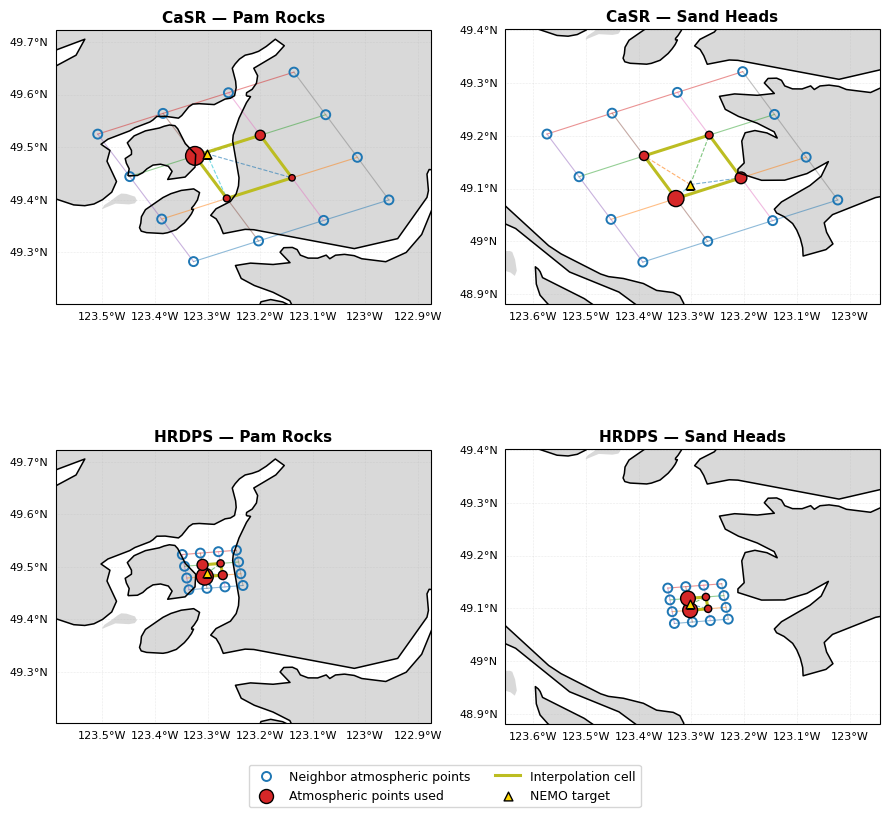

In [13]:


import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# Helper: convert longitude from 0--360 to -180--180
# ============================================================

def lon180(lon):
    """
    Convert longitude from 0--360 to -180--180.

    Works with:
        scalar
        numpy array
        pandas Series
    """
    return ((lon + 180) % 360) - 180


# ============================================================
# Helper: calculate common extent for the same station
# ============================================================

def get_common_extent(
    dfs,
    station,
    padding=0.08,
):
    """
    Calculate one common map extent for the same station
    using multiple atmospheric datasets.

    Example:
        CaSR Pam Rocks + HRDPS Pam Rocks
        -> same map extent
    """

    all_lon = []
    all_lat = []

    # atmospheric points from all datasets
    for df in dfs:

        plot_lon = lon180(df["atmos_lon"].values)

        all_lon.extend(plot_lon)
        all_lat.extend(df["atmos_lat"].values)

    # include the NEMO target point
    all_lon.append(lon180(station["lon"]))
    all_lat.append(station["lat"])

    all_lon = np.asarray(all_lon)
    all_lat = np.asarray(all_lat)

    lon_min = all_lon.min() - padding
    lon_max = all_lon.max() + padding
    lat_min = all_lat.min() - padding
    lat_max = all_lat.max() + padding

    return [
        lon_min,
        lon_max,
        lat_min,
        lat_max,
    ]


# ============================================================
# Plot one panel
# ============================================================

def plot_atmos_weights_map(
    ax,
    df,
    station,
    title,
    extent=None,
    padding=0.08,
):
    """
    Plot atmospheric source-grid geometry for one NEMO point.

    Shows:
        - NEMO target point
        - 4 atmospheric points actually used
        - 12 neighboring atmospheric grid points
        - atmospheric grid lines
        - interpolation cell
        - lines from NEMO target to used atmospheric points
        - coastline / land

    Parameters
    ----------
    ax : cartopy GeoAxes

    df : pandas.DataFrame
        Output from get_source_and_neighbors().

    station : dict
        Example:
            {
                "y": 502,
                "x": 341,
                "lat": 49.487434,
                "lon": -123.30153,
            }

    title : str

    extent : list or None
        [lon_min, lon_max, lat_min, lat_max]

    padding : float
        Used only if extent is None.
    """

    # --------------------------------------------------------
    # Copy dataframe
    # --------------------------------------------------------

    df = df.copy()

    # Convert atmospheric longitude
    df["plot_lon"] = lon180(df["atmos_lon"])

    # Separate used and neighbor points
    used = df[df["point_type"] == "used"].copy()
    neighbors = df[df["point_type"] == "neighbor"].copy()

    # Target location
    target_lon = lon180(station["lon"])
    target_lat = station["lat"]


    # ========================================================
    # Background
    # ========================================================

    ax.add_feature(
        cfeature.OCEAN,
        facecolor="white",
        zorder=0,
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="0.85",
        zorder=0,
    )

    ax.add_feature(
        cfeature.COASTLINE,
        linewidth=1.1,
        zorder=10,
    )


    # ========================================================
    # Atmospheric grid lines
    #
    # Connect same-ilat points in increasing ilon,
    # and same-ilon points in increasing ilat.
    # ========================================================

    # horizontal-ish rows
    for ilat in sorted(df["atmos_ilat"].unique()):

        row = (
            df[df["atmos_ilat"] == ilat]
            .sort_values("atmos_ilon")
        )

        if len(row) >= 2:

            ax.plot(
                row["plot_lon"],
                row["atmos_lat"],
                "-",
                linewidth=0.8,
                alpha=0.5,
                transform=ccrs.PlateCarree(),
                zorder=1,
            )


    # vertical-ish columns
    for ilon in sorted(df["atmos_ilon"].unique()):

        col = (
            df[df["atmos_ilon"] == ilon]
            .sort_values("atmos_ilat")
        )

        if len(col) >= 2:

            ax.plot(
                col["plot_lon"],
                col["atmos_lat"],
                "-",
                linewidth=0.8,
                alpha=0.5,
                transform=ccrs.PlateCarree(),
                zorder=1,
            )


    # ========================================================
    # Neighbor points
    # ========================================================

    ax.scatter(
        neighbors["plot_lon"],
        neighbors["atmos_lat"],
        s=42,
        marker="o",
        facecolors="none",
        edgecolors="tab:blue",
        linewidths=1.4,
        transform=ccrs.PlateCarree(),
        zorder=4,
        label="Neighbor atmospheric points",
    )


    # ========================================================
    # 4 atmospheric points actually used
    #
    # Marker size proportional to weight
    # ========================================================

    marker_sizes = 20 + 200 * used["weight"].values

    ax.scatter(
        used["plot_lon"],
        used["atmos_lat"],
        s=marker_sizes,
        marker="o",
        facecolors="tab:red",
        edgecolors="black",
        linewidths=1.0,
        transform=ccrs.PlateCarree(),
        zorder=6,
        label="Atmospheric points used",
    )


    # ========================================================
    # Label used atmospheric points
    # ========================================================

    for _, row in used.iterrows():

        source_number = int(row["source_number"])

        # ax.annotate(
        #     f"S{source_number}\n"
        #     f"w={row['weight']:.3f}",
        #     xy=(
        #         row["plot_lon"],
        #         row["atmos_lat"],
        #     ),
        #     xytext=(6, 6),
        #     textcoords="offset points",
        #     fontsize=7.5,
        #     transform=ccrs.PlateCarree(),
        #     zorder=9,
        # )


    # ========================================================
    # Draw actual 4-point interpolation cell
    #
    # Sort by angle around cell center so lines form a polygon.
    # ========================================================

    center_lon = used["plot_lon"].mean()
    center_lat = used["atmos_lat"].mean()

    angle = np.arctan2(
        used["atmos_lat"].values - center_lat,
        used["plot_lon"].values - center_lon,
    )

    order = np.argsort(angle)

    used_polygon = used.iloc[order]

    poly_lon = np.append(
        used_polygon["plot_lon"].values,
        used_polygon["plot_lon"].values[0],
    )

    poly_lat = np.append(
        used_polygon["atmos_lat"].values,
        used_polygon["atmos_lat"].values[0],
    )

    ax.plot(
        poly_lon,
        poly_lat,
        "-",
        linewidth=2.2,
        transform=ccrs.PlateCarree(),
        zorder=5,
        label="Interpolation cell",
    )


    # ========================================================
    # NEMO target
    # ========================================================

    ax.scatter(
        target_lon,
        target_lat,
        marker="^",
        s=40,
        facecolors="gold",
        edgecolors="black",
        linewidths=1.0,
        transform=ccrs.PlateCarree(),
        zorder=8,
        label="NEMO target",
    )


    # ========================================================
    # Lines from NEMO target to the 4 used points
    # ========================================================

    for _, row in used.iterrows():

        ax.plot(
            [
                target_lon,
                row["plot_lon"],
            ],
            [
                target_lat,
                row["atmos_lat"],
            ],
            "--",
            linewidth=0.8,
            alpha=0.6,
            transform=ccrs.PlateCarree(),
            zorder=3,
        )


    # ========================================================
    # Map extent
    # ========================================================

    if extent is None:

        all_lon = np.concatenate(
            [
                df["plot_lon"].values,
                [target_lon],
            ]
        )

        all_lat = np.concatenate(
            [
                df["atmos_lat"].values,
                [target_lat],
            ]
        )

        extent = [
            all_lon.min() - padding,
            all_lon.max() + padding,
            all_lat.min() - padding,
            all_lat.max() + padding,
        ]

    ax.set_extent(
        extent,
        crs=ccrs.PlateCarree(),
    )


    # ========================================================
    # Latitude / longitude grid labels
    # ========================================================

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.4,
        alpha=0.5,
        linestyle=":",
    )

    gl.top_labels = False
    gl.right_labels = False

    gl.xlabel_style = {
        "size": 8
    }

    gl.ylabel_style = {
        "size": 8
    }


    # ========================================================
    # Title
    # ========================================================

    ax.set_title(
        title,
        fontsize=11,
        fontweight="bold",
    )


# ============================================================
# Common extents
#
# IMPORTANT:
# CaSR and HRDPS for the SAME station use exactly
# the same map range.
# ============================================================

extent_pam = get_common_extent(
    [
        casr_results["Pam Rocks"],
        hrdps_results["Pam Rocks"],
    ],
    stations["Pam Rocks"],
    padding=0.08,
)


extent_sand = get_common_extent(
    [
        casr_results["Sand Heads"],
        hrdps_results["Sand Heads"],
    ],
    stations["Sand Heads"],
    padding=0.08,
)


print("Pam Rocks extent:")
print(extent_pam)

print()

print("Sand Heads extent:")
print(extent_sand)


# ============================================================
# Make 2 x 2 figure
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(9, 9),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
)


# ============================================================
# Row 1: CaSR
# ============================================================

plot_atmos_weights_map(
    axes[0, 0],
    casr_results["Pam Rocks"],
    stations["Pam Rocks"],
    title="CaSR — Pam Rocks",
    extent=extent_pam,
)


plot_atmos_weights_map(
    axes[0, 1],
    casr_results["Sand Heads"],
    stations["Sand Heads"],
    title="CaSR — Sand Heads",
    extent=extent_sand,
)


# ============================================================
# Row 2: HRDPS
# ============================================================

plot_atmos_weights_map(
    axes[1, 0],
    hrdps_results["Pam Rocks"],
    stations["Pam Rocks"],
    title="HRDPS — Pam Rocks",
    extent=extent_pam,
)


plot_atmos_weights_map(
    axes[1, 1],
    hrdps_results["Sand Heads"],
    stations["Sand Heads"],
    title="HRDPS — Sand Heads",
    extent=extent_sand,
)


# ============================================================
# Common legend
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

# remove duplicate labels just in case
unique = {}

for h, label in zip(handles, labels):
    if label not in unique:
        unique[label] = h

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=2,
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, 0.015),
)





# ============================================================
# Layout
# ============================================================

plt.tight_layout()


# ============================================================
# Optional save
# ============================================================

# plt.savefig(
#     "NEMO_atmospheric_interpolation_geometry.png",
#     dpi=300,
#     bbox_inches="tight",
# )


plt.show()



## Air temperature at grid points

### Extract grid point temperature

In [1]:
# Extract

# ============================================================
# Extract tair at the 4 interpolation source points
# for Pam Rocks and Sand Heads
#
# CaSR  : 8 source points total
# HRDPS : 8 source points total
#
# Also calculate weighted interpolated station temperature
# ============================================================

import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
import glob


# ============================================================
# 1. Paths
# ============================================================

casr_dir = Path(
    "/ocean/jqiu/forcings/CaSR"
)

hrdps_dir = Path(
    "/results/forcing/atmospheric/continental2.5/nemo_forcing"
)

output_dir = Path(
    "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_comparison/Analysis_weights"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# March 2023 files
casr_files = sorted(
    glob.glob(
        str(casr_dir / "CaSR_y2023m03d*.nc")
    )
)

hrdps_files = sorted(
    glob.glob(
        str(hrdps_dir / "hrdps_y2023m03d*.nc")
    )
)

print(f"CaSR files  : {len(casr_files)}")
print(f"HRDPS files : {len(hrdps_files)}")


# ============================================================
# 2. Four source points and interpolation weights
# ============================================================
#
# y = ilat
# x = ilon
#
# The weights below are copied directly from your
# interpolation-index output.
# ============================================================

source_points = {

    # --------------------------------------------------------
    # CaSR
    # --------------------------------------------------------

    "CaSR": {

        "PamRocks": [
            {
                "point": 1,
                "y": 58,
                "x": 36,
                "weight": 0.8099528243,
            },
            {
                "point": 2,
                "y": 57,
                "x": 36,
                "weight": 0.0239716401,
            },
            {
                "point": 3,
                "y": 58,
                "x": 37,
                "weight": 0.1613015984,
            },
            {
                "point": 4,
                "y": 57,
                "x": 37,
                "weight": 0.0047739371,
            },
        ],

        "SandHeads": [
            {
                "point": 1,
                "y": 54,
                "x": 34,
                "weight": 0.5675647174,
            },
            {
                "point": 2,
                "y": 55,
                "x": 34,
                "weight": 0.1233862179,
            },
            {
                "point": 3,
                "y": 54,
                "x": 35,
                "weight": 0.2538607824,
            },
            {
                "point": 4,
                "y": 55,
                "x": 35,
                "weight": 0.0551882822,
            },
        ],
    },

    # --------------------------------------------------------
    # HRDPS
    # --------------------------------------------------------

    "HRDPS": {

        "PamRocks": [
            {
                "point": 1,
                "y": 135,
                "x": 110,
                "weight": 0.6461993583,
            },
            {
                "point": 2,
                "y": 136,
                "x": 110,
                "weight": 0.2141754176,
            },
            {
                "point": 3,
                "y": 135,
                "x": 111,
                "weight": 0.1048679398,
            },
            {
                "point": 4,
                "y": 136,
                "x": 111,
                "weight": 0.0347572843,
            },
        ],

        "SandHeads": [
            {
                "point": 1,
                "y": 118,
                "x": 108,
                "weight": 0.4704031405,
            },
            {
                "point": 2,
                "y": 119,
                "x": 108,
                "weight": 0.4576466227,
            },
            {
                "point": 3,
                "y": 118,
                "x": 109,
                "weight": 0.0364696148,
            },
            {
                "point": 4,
                "y": 119,
                "x": 109,
                "weight": 0.0354806220,
            },
        ],
    },
}


# ============================================================
# 3. Check weights
# ============================================================

for model in source_points:

    for station in source_points[model]:

        weight_sum = sum(
            p["weight"]
            for p in source_points[model][station]
        )

        print(
            f"{model:6s} {station:10s}: "
            f"sum(weights) = {weight_sum:.12f}"
        )


# ============================================================
# 4. Open datasets
#
# Only tair is required.
# nav_lat/nav_lon remain available as coordinates/variables.
# ============================================================

ds_casr = xr.open_mfdataset(
    casr_files,
    combine="by_coords",
    parallel=True,
    chunks={"time_counter": 24},
)

ds_hrdps = xr.open_mfdataset(
    hrdps_files,
    combine="by_coords",
    parallel=True,
    chunks={"time_counter": 24},
)


datasets = {
    "CaSR": ds_casr,
    "HRDPS": ds_hrdps,
}


# ============================================================
# 5. Temperature conversion
# ============================================================

def temperature_to_celsius(da):

    units = str(
        da.attrs.get("units", "")
    ).strip().lower()

    print(
        f"tair units from file: {da.attrs.get('units', 'unknown')}"
    )

    # Kelvin
    if units in [
        "k",
        "kelvin",
        "degrees_k",
        "degree_k",
    ]:
        return da - 273.15

    # Celsius
    elif units in [
        "c",
        "degc",
        "degree_celsius",
        "degrees_celsius",
        "celsius",
    ]:
        return da

    # Atmospheric forcing tair is normally Kelvin.
    # If metadata are missing, use a numerical check.
    else:

        sample = float(
            da.isel(
                time_counter=0,
                y=0,
                x=0,
            ).values
        )

        if sample > 100:
            print(
                "WARNING: tair units not identified; "
                "values look like Kelvin. "
                "Converting to Celsius."
            )
            return da - 273.15

        else:
            print(
                "WARNING: tair units not identified; "
                "assuming Celsius."
            )
            return da


# ============================================================
# 6. Extract one model
# ============================================================

def extract_model_source_points(
    ds,
    model_name,
    station_points,
):

    # Temperature in Celsius
    tair_C = temperature_to_celsius(
        ds["tair"]
    )

    all_dfs = []

    # --------------------------------------------------------
    # Loop over two stations
    # --------------------------------------------------------

    for station_name, points in station_points.items():

        print(
            "\n"
            "===================================================="
        )
        print(
            f"{model_name} - {station_name}"
        )
        print(
            "===================================================="
        )

        # ----------------------------------------------------
        # Loop over four interpolation source points
        # ----------------------------------------------------

        for p in points:

            point_number = p["point"]
            y_idx = p["y"]
            x_idx = p["x"]
            weight = p["weight"]

            # Extract temperature
            point_da = tair_C.isel(
                y=y_idx,
                x=x_idx,
            )

            # Grid coordinate
            grid_lat = float(
                ds["nav_lat"].isel(
                    y=y_idx,
                    x=x_idx,
                ).values
            )

            grid_lon = float(
                ds["nav_lon"].isel(
                    y=y_idx,
                    x=x_idx,
                ).values
            )

            grid_lon_180 = (
                grid_lon - 360
                if grid_lon > 180
                else grid_lon
            )

            print(
                f"point {point_number}: "
                f"(y,x)=({y_idx},{x_idx}), "
                f"lat={grid_lat:.6f}, "
                f"lon={grid_lon_180:.6f}, "
                f"weight={weight:.10f}"
            )

            # ------------------------------------------------
            # Make dataframe
            # ------------------------------------------------

            df = point_da.to_dataframe(
                name="tair_C"
            ).reset_index()

            # Keep only useful dimensions
            drop_cols = [
                c
                for c in ["x", "y"]
                if c in df.columns
            ]

            if drop_cols:
                df = df.drop(
                    columns=drop_cols
                )

            # Metadata
            df["model"] = model_name
            df["station"] = station_name
            df["source_point"] = point_number

            df["grid_y"] = y_idx
            df["grid_x"] = x_idx

            df["grid_lat"] = grid_lat
            df["grid_lon"] = grid_lon
            df["grid_lon_180"] = grid_lon_180

            df["weight"] = weight

            # Weighted contribution from this source point
            df["weighted_tair_C"] = (
                df["tair_C"] * weight
            )

            # Desired order
            df = df[
                [
                    "time_counter",
                    "model",
                    "station",
                    "source_point",
                    "grid_y",
                    "grid_x",
                    "grid_lat",
                    "grid_lon",
                    "grid_lon_180",
                    "weight",
                    "tair_C",
                    "weighted_tair_C",
                ]
            ]

            all_dfs.append(df)

    # --------------------------------------------------------
    # Combine all 8 source-point time series for the model
    # --------------------------------------------------------

    result = pd.concat(
        all_dfs,
        ignore_index=True
    )

    result = result.sort_values(
        [
            "station",
            "source_point",
            "time_counter",
        ]
    ).reset_index(drop=True)

    return result


# ============================================================
# 7. Extract CaSR and HRDPS
# ============================================================

df_casr = extract_model_source_points(
    ds=ds_casr,
    model_name="CaSR",
    station_points=source_points["CaSR"],
)

df_hrdps = extract_model_source_points(
    ds=ds_hrdps,
    model_name="HRDPS",
    station_points=source_points["HRDPS"],
)


# ============================================================
# 8. Combine all 16 source points
# ============================================================

df_all_points = pd.concat(
    [
        df_casr,
        df_hrdps,
    ],
    ignore_index=True
)


# ============================================================
# 9. Save all source-point temperature time series
#
# Long-format CSV:
#
# one row =
# one time × one model × one station × one source point
# ============================================================

source_output = (
    output_dir /
    "CaSR_HRDPS_4sourcepoints_tair_202303.csv"
)

df_all_points.to_csv(
    source_output,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S",
)

print(
    f"\nSaved source-point data:\n{source_output}"
)


# ============================================================
# 10. Calculate weighted station temperature
#
# T_station = sum(weight_i * T_i)
# ============================================================

df_weighted = (
    df_all_points
    .groupby(
        [
            "time_counter",
            "model",
            "station",
        ],
        as_index=False,
    )
    ["weighted_tair_C"]
    .sum()
    .rename(
        columns={
            "weighted_tair_C":
            "tair_weighted_C"
        }
    )
)

df_weighted = df_weighted.sort_values(
    [
        "station",
        "model",
        "time_counter",
    ]
).reset_index(drop=True)


weighted_output = (
    output_dir /
    "CaSR_HRDPS_weighted_tair_202303.csv"
)

df_weighted.to_csv(
    weighted_output,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S",
)

print(
    f"\nSaved weighted station temperature:\n"
    f"{weighted_output}"
)


# ============================================================
# 11. Also save one convenient wide-format CSV
#
# Columns look like:
# CaSR_PamRocks_P1
# CaSR_PamRocks_P2
# ...
# HRDPS_SandHeads_P4
#
# Useful for quickly checking the 16 source-point series.
# ============================================================

df_wide = (
    df_all_points
    .assign(
        series_name=lambda x:
            x["model"]
            + "_"
            + x["station"]
            + "_P"
            + x["source_point"].astype(str)
    )
    .pivot(
        index="time_counter",
        columns="series_name",
        values="tair_C",
    )
    .sort_index()
    .reset_index()
)

wide_output = (
    output_dir /
    "CaSR_HRDPS_16sourcepoints_tair_wide_202303.csv"
)

df_wide.to_csv(
    wide_output,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S",
)

print(
    f"\nSaved wide-format source-point data:\n"
    f"{wide_output}"
)


# ============================================================
# 12. Close files
# ============================================================

ds_casr.close()
ds_hrdps.close()

print("\nAll done.")

CaSR files  : 31
HRDPS files : 31
CaSR   PamRocks  : sum(weights) = 0.999999999900
CaSR   SandHeads : sum(weights) = 0.999999999900
HRDPS  PamRocks  : sum(weights) = 1.000000000000
HRDPS  SandHeads : sum(weights) = 1.000000000000
tair units from file: K

CaSR - PamRocks
point 1: (y,x)=(58,36), lat=49.483242, lon=-123.323914, weight=0.8099528243
point 2: (y,x)=(57,36), lat=49.402325, lon=-123.263321, weight=0.0239716401
point 3: (y,x)=(58,37), lat=49.522491, lon=-123.199615, weight=0.1613015984
point 4: (y,x)=(57,37), lat=49.441509, lon=-123.139206, weight=0.0047739371

CaSR - SandHeads
point 1: (y,x)=(54,34), lat=49.081009, lon=-123.329330, weight=0.5675647174
point 2: (y,x)=(55,34), lat=49.161884, lon=-123.389679, weight=0.1233862179
point 3: (y,x)=(54,35), lat=49.120274, lon=-123.206131, weight=0.2538607824
point 4: (y,x)=(55,35), lat=49.201210, lon=-123.266296, weight=0.0551882822
tair units from file: K

HRDPS - PamRocks
point 1: (y,x)=(135,110), lat=49.481496, lon=-123.305272, wei

### Grid point time series

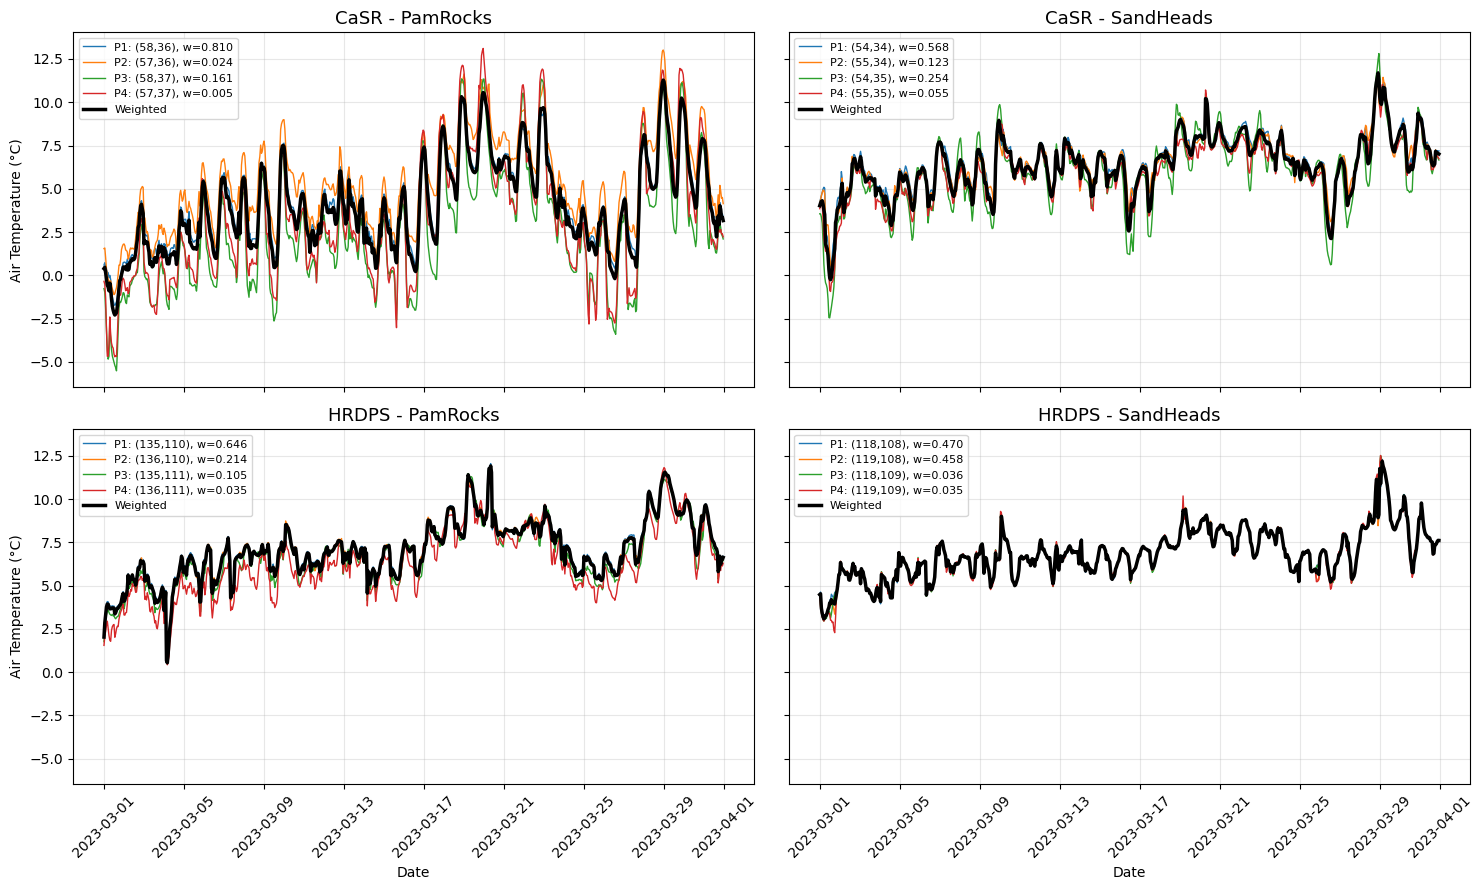

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 1. Input
# ============================================================


path_points = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_comparison/Analysis_weights/CaSR_HRDPS_4sourcepoints_tair_202303.csv'


# ============================================================
# 2. Read source-point temperature
# ============================================================

df = pd.read_csv(
    path_points
)

df["time_counter"] = pd.to_datetime(
    df["time_counter"]
)


# ============================================================
# 3. Plot
#
# rows    = models
# columns = stations
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 9),
    sharex=True,
    sharey=True,
)


models = [
    "CaSR",
    "HRDPS",
]

stations = [
    "PamRocks",
    "SandHeads",
]


for row, model in enumerate(models):

    for col, station in enumerate(stations):

        ax = axes[row, col]

        sub = df[
            (df["model"] == model)
            &
            (df["station"] == station)
        ].copy()

        # --------------------------------------------
        # Plot each of the four source points
        # --------------------------------------------

        for point_number in [1, 2, 3, 4]:

            p = sub[
                sub["source_point"]
                == point_number
            ].sort_values(
                "time_counter"
            )

            # Retrieve point metadata
            y_idx = int(
                p["grid_y"].iloc[0]
            )

            x_idx = int(
                p["grid_x"].iloc[0]
            )

            weight = float(
                p["weight"].iloc[0]
            )

            ax.plot(
                p["time_counter"],
                p["tair_C"],
                linewidth=1.0,
                label=(
                    f"P{point_number}: "
                    f"({y_idx},{x_idx}), "
                    f"w={weight:.3f}"
                ),
            )

        # --------------------------------------------
        # Weighted interpolation
        # --------------------------------------------

        weighted = (
            sub
            .groupby(
                "time_counter"
            )
            ["weighted_tair_C"]
            .sum()
        )

        ax.plot(
            weighted.index,
            weighted.values,
            linewidth=2.5,
            color="black",
            label="Weighted",
        )

        ax.set_title(
            f"{model} - {station}",
            fontsize=13,
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        ax.legend(
            fontsize=8,
        )

        ax.tick_params(
            axis="x",
            rotation=45,
        )


# ============================================================
# 4. Labels
# ============================================================

axes[0, 0].set_ylabel(
    "Air Temperature (°C)"
)

axes[1, 0].set_ylabel(
    "Air Temperature (°C)"
)

axes[1, 0].set_xlabel(
    "Date"
)

axes[1, 1].set_xlabel(
    "Date"
)


plt.tight_layout()

plt.show()

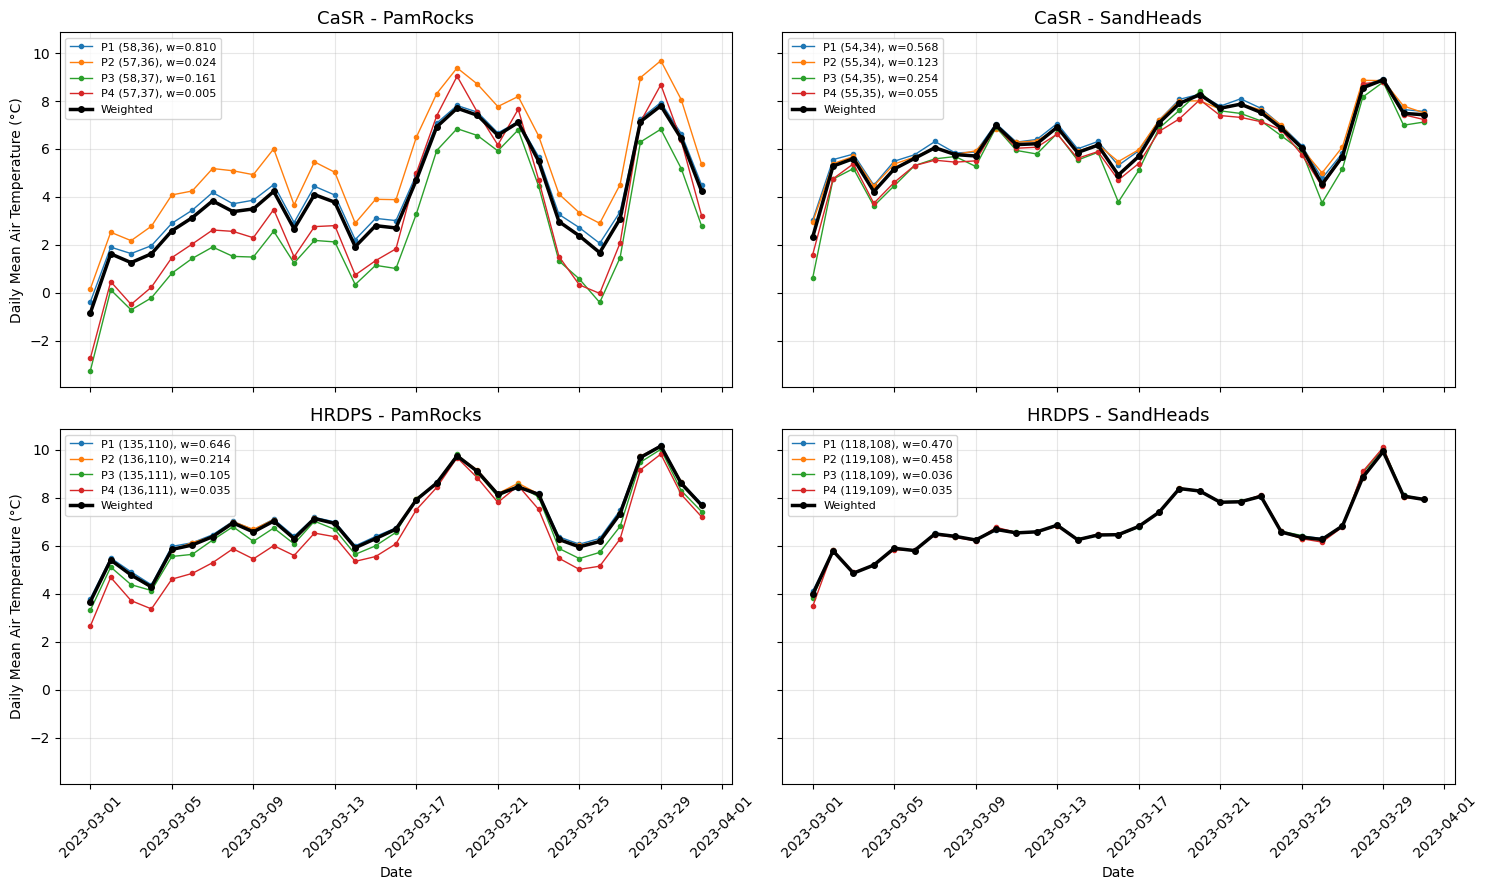

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 1. Input
# ============================================================



path_points =  '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_comparison/Analysis_weights/CaSR_HRDPS_4sourcepoints_tair_202303.csv'


# ============================================================
# 2. Read data
# ============================================================

df = pd.read_csv(path_points)

df["time_counter"] = pd.to_datetime(
    df["time_counter"]
)


# ============================================================
# 3. Calculate daily mean for each source point
# ============================================================

daily_points = (
    df
    .set_index("time_counter")
    .groupby(
        [
            "model",
            "station",
            "source_point",
            "grid_y",
            "grid_x",
            "weight",
        ]
    )["tair_C"]
    .resample("1D")
    .mean()
    .reset_index()
)


# ============================================================
# 4. Calculate weighted daily station temperature
#
# Because the weights are constant:
#
# daily weighted T =
# sum(weight_i * daily mean T_i)
# ============================================================

daily_points["weighted_tair_C"] = (
    daily_points["tair_C"]
    * daily_points["weight"]
)

daily_weighted = (
    daily_points
    .groupby(
        [
            "time_counter",
            "model",
            "station",
        ],
        as_index=False,
    )["weighted_tair_C"]
    .sum()
)


# ============================================================
# 5. Plot daily source-point temperatures
#
#       Pam Rocks      Sand Heads
# CaSR
# HRDPS
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 9),
    sharex=True,
    sharey=True,
)

models = [
    "CaSR",
    "HRDPS",
]

stations = [
    "PamRocks",
    "SandHeads",
]


for row, model in enumerate(models):

    for col, station in enumerate(stations):

        ax = axes[row, col]

        sub = daily_points[
            (daily_points["model"] == model)
            &
            (daily_points["station"] == station)
        ].copy()

        # ----------------------------------------------------
        # Four interpolation source points
        # ----------------------------------------------------

        for point_number in [1, 2, 3, 4]:

            p = sub[
                sub["source_point"] == point_number
            ].sort_values(
                "time_counter"
            )

            y_idx = int(
                p["grid_y"].iloc[0]
            )

            x_idx = int(
                p["grid_x"].iloc[0]
            )

            weight = float(
                p["weight"].iloc[0]
            )

            ax.plot(
                p["time_counter"],
                p["tair_C"],
                marker="o",
                markersize=3,
                linewidth=1.0,
                label=(
                    f"P{point_number} "
                    f"({y_idx},{x_idx}), "
                    f"w={weight:.3f}"
                ),
            )

        # ----------------------------------------------------
        # Weighted station temperature
        # ----------------------------------------------------

        weighted = daily_weighted[
            (daily_weighted["model"] == model)
            &
            (daily_weighted["station"] == station)
        ].sort_values(
            "time_counter"
        )

        ax.plot(
            weighted["time_counter"],
            weighted["weighted_tair_C"],
            color="black",
            marker="o",
            markersize=4,
            linewidth=2.5,
            label="Weighted",
        )

        # ----------------------------------------------------
        # Plot settings
        # ----------------------------------------------------

        ax.set_title(
            f"{model} - {station}",
            fontsize=13,
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        ax.legend(
            fontsize=8,
        )

        ax.tick_params(
            axis="x",
            rotation=45,
        )


# ============================================================
# 6. Axis labels
# ============================================================

axes[0, 0].set_ylabel(
    "Daily Mean Air Temperature (°C)"
)

axes[1, 0].set_ylabel(
    "Daily Mean Air Temperature (°C)"
)

axes[1, 0].set_xlabel(
    "Date"
)

axes[1, 1].set_xlabel(
    "Date"
)


plt.tight_layout()


plt.show()